In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path

TARGET_CRS = "EPSG:5070"

In [5]:
folder = Path("../../../census")

IllinoisCensus = {}

for file in folder.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        IllinoisCensus[file.name] = pd.read_csv(file)

In [9]:
ILTracts2020 = gpd.read_file('../../raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp').to_crs(TARGET_CRS)
ILPlaces = gpd.read_file("../../raw/IL/tl_2025_17_place/tl_2025_17_place.shp").to_crs(TARGET_CRS)

In [46]:
CollarArea = gpd.read_file("../IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)

In [30]:
ILTracts2020["GEOID"] = ILTracts2020["GEOID"].astype(str)
ILPlaces["GEOID"] = ILPlaces["GEOID"].astype(str)

In [44]:
# Calculate tract/community-area polygon overlaps
overlaps = gpd.overlay(
    ILTracts2020,
    ILPlaces[
        ["GEOID", "NAME", "geometry"]
    ].rename(
        columns={
            "GEOID": "PLACE_GEOID",
            "NAME": "PLACE_NAME",
        }
    ),
    how="intersection",
)

# Calculate overlap area
overlaps["overlap_area"] = overlaps.geometry.area

# Keep the community area with the largest overlap per tract
largest_overlap = (
    overlaps
    .sort_values("overlap_area", ascending=False)
    .drop_duplicates(subset="GEOID")
)

# Attach the classification to the original tract polygons
tracts_classified = ILTracts2020.merge(
    largest_overlap[
        ["GEOID", "PLACE_GEOID", "PLACE_NAME"]
    ],
    on="GEOID",
    how="left",
)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 6098 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [47]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

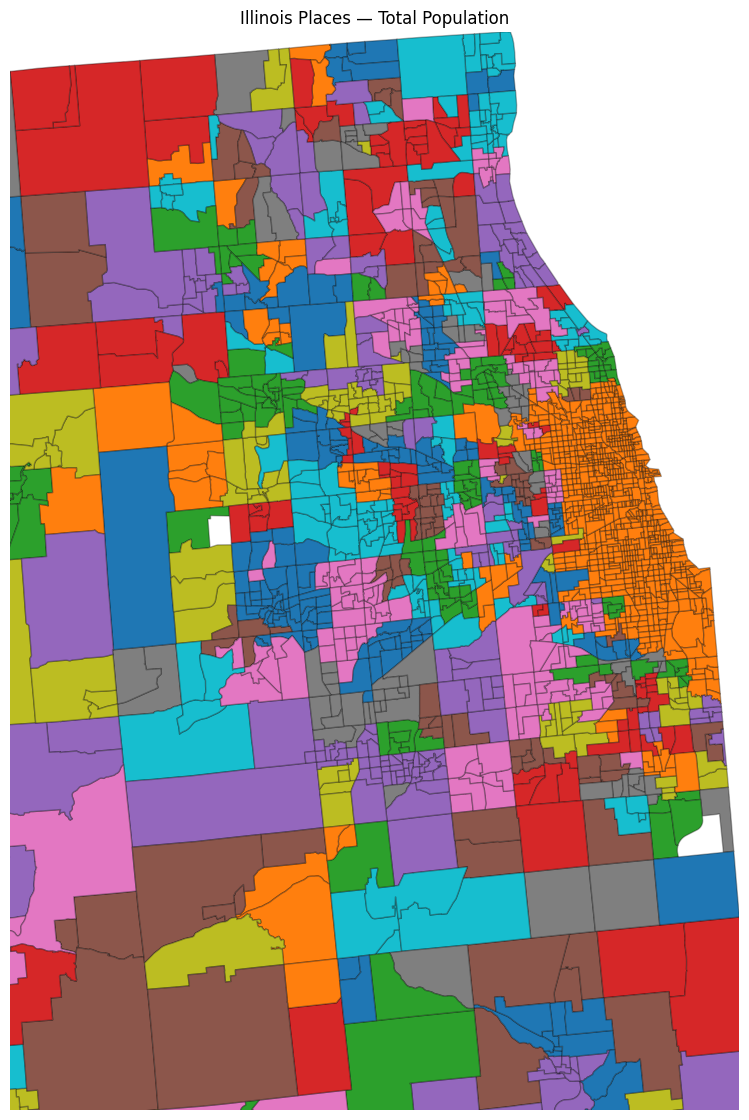

In [48]:
fig, ax = plt.subplots(figsize=(14, 14))

tracts_classified.plot(
    ax=ax,
    column="PLACE_NAME",
    categorical=True,
    legend=False,
    edgecolor="#00000050",
    linewidth=1,
)

ZoomToTheExtentOf(ax, CollarArea)

ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")
plt.show()
